<a href="https://colab.research.google.com/github/LuisFelipeVelasco/Generative_AI_Experiments/blob/main/Notebooks/random_text_generator_using_character_frecuency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LIBRARIES IMPORTATION**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

**CHARGE TEXT**

In [2]:
!wget https://raw.githubusercontent.com/LuisFelipeVelasco/Generative_AI_Experiments/main/Sources/text.txt

--2026-06-11 17:55:15--  https://raw.githubusercontent.com/LuisFelipeVelasco/Generative_AI_Experiments/main/Sources/text.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9989 (9.8K) [text/plain]
Saving to: ‘text.txt’

text.txt            100%[===================>]   9.75K  --.-KB/s    in 0s      

2026-06-11 17:55:15 (103 MB/s) - ‘text.txt’ saved [9989/9989]



**READ TEXT**

In [3]:
with open('text.txt', 'r') as file:
    content = file.read()
    print(content)

There is a story that runs beneath every calculation ever performed, beneath every line of code ever written, beneath every theorem ever proved. It is a story about the human need to count, to measure, to predict, and ultimately to build machines that can do all of these things faster and more reliably than any single mind. That story begins not in a university lecture hall or a computing laboratory, but in the mud and grain of ancient river valleys, where the earliest civilisations discovered that the world could be made to yield its secrets if only one found the right way to ask. Mathematics and computer science are often treated as distinct disciplines today, separated by departments and journals and professional identities. Yet the deeper one digs into the history of either field, the more clearly one sees that they are two expressions of the same underlying impulse: the desire to reduce complexity to pattern, and to harness pattern for practical ends.
The earliest unambiguous evid

**CALCULATE THE FRECUENCY OF EACH CHARACTER**

In [4]:
#convert all the text in lowercase
content=content.lower()
#convert the text into a list of characters
content_list=list(content)
#convert the list of characters into a numpy array
characters_list=np.array(content_list)
#Calculate the probabilities:
unique_chars,char_count=np.unique(characters_list,return_counts=True)
frecuency_chars=(char_count*100)/len(characters_list)


**PLOT FRECUENCY**

([<matplotlib.axis.YTick at 0x793156ba97f0>,
 [Text(0, 0, '0'),
  Text(0, 1, '1'),
  Text(0, 2, '2'),
  Text(0, 3, '3'),
  Text(0, 4, '4'),
  Text(0, 5, '5'),
  Text(0, 6, '6'),
  Text(0, 7, '7'),
  Text(0, 8, '8'),
  Text(0, 9, '9'),
  Text(0, 10, '10'),
  Text(0, 11, '11'),
  Text(0, 12, '12'),
  Text(0, 13, '13'),
  Text(0, 14, '14'),
  Text(0, 15, '15')])

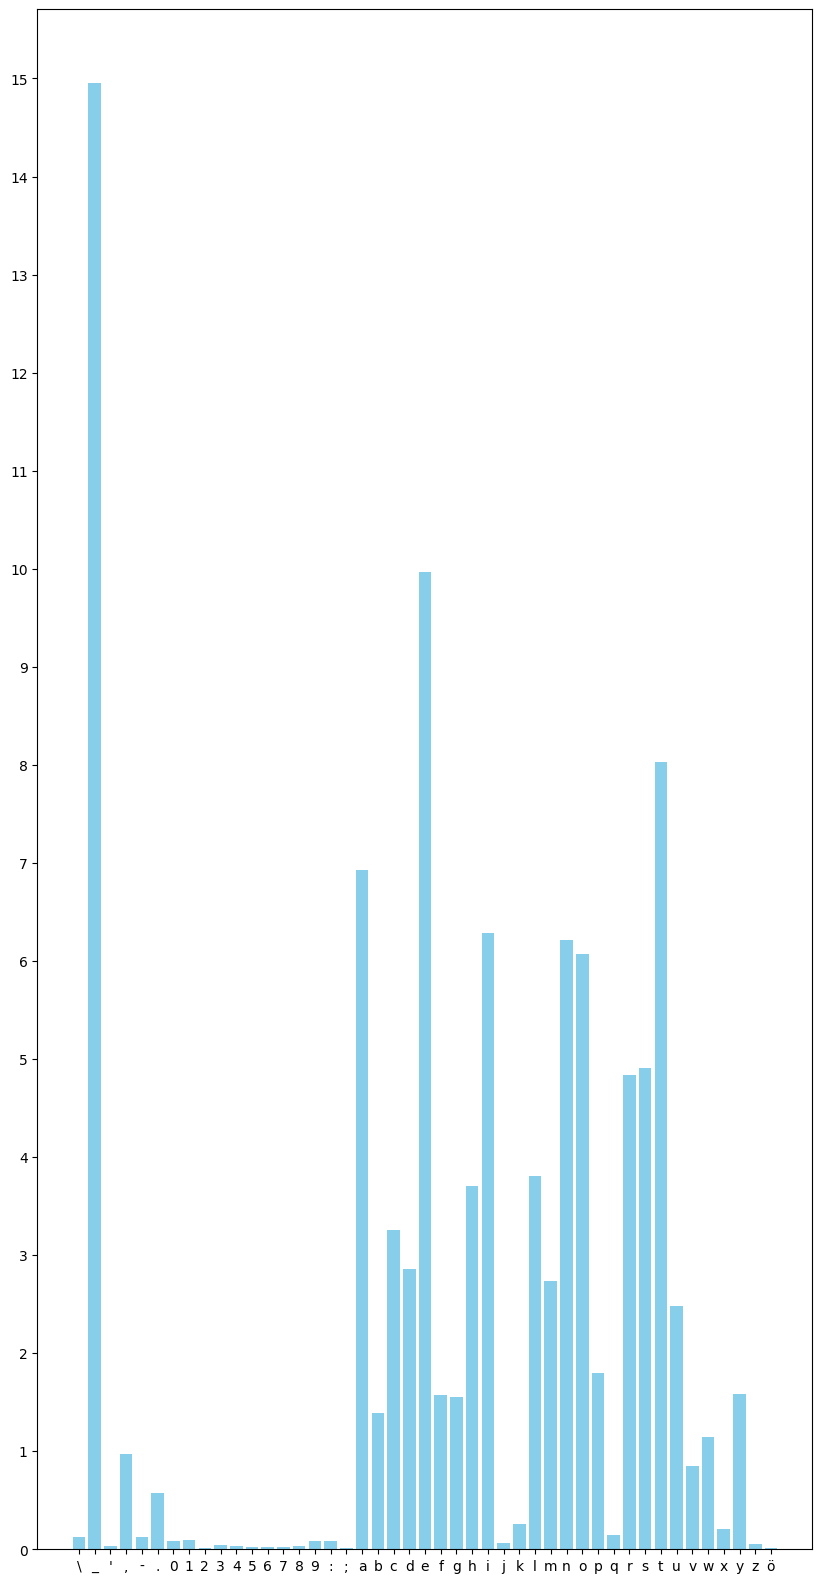

In [5]:
unique_chars_bar=unique_chars.copy()
for i,char in enumerate(unique_chars):
    if(char=='\n'):
        unique_chars_bar[i]="\\n"
    if(char==' '):
        unique_chars_bar[i]="_"
plt.figure(figsize=(10, 20))
plt.bar(unique_chars_bar, frecuency_chars, color='skyblue')
plt.yticks(range(0, 16,1))

**CHARACTER DISTRIBUTION SAMPLIN  FUNCTION**

In [6]:
from enum import unique
def sample_from_character_distribution(characters,char_count):

  """
Sample characters from a character distribution.

Parameters
----------
characters : array-like
    Characters used to determine the sample size.
char_count : numpy.ndarray
    Character occurrence counts.

Returns
-------
frequency_chars : numpy.ndarray
    Simulated character frequencies (%).
index_char : numpy.ndarray
    Indices of the sampled characters.
"""

  number_random_numbers=len(characters)
  max_random_number=len(characters)
  #Generate a np array with random numbers
  random_numbers=np.random.choice(max_random_number,number_random_numbers)
  #Generate a np array with the cumulutive sum of char_count
  char_count_sum=np.cumsum(char_count)
  #Generate a np array with the index of the char that correspond to each random number
  index_char=np.searchsorted(char_count_sum, random_numbers)
  char_random_count=np.zeros(len(unique_chars))
  unique_index_chars,index_char_counts=np.unique(index_char,return_counts=True)
  # Map the simulated frequencies back to their absolute character index positions
  char_random_count[unique_index_chars] = index_char_counts
  frecuency_chars=(char_random_count*100)/len(random_numbers)
  return frecuency_chars , index_char



**PLOT FRECUENCY OF CHARACTERS**

([<matplotlib.axis.YTick at 0x79315412e300>,
 [Text(0, 0, '0'),
  Text(0, 1, '1'),
  Text(0, 2, '2'),
  Text(0, 3, '3'),
  Text(0, 4, '4'),
  Text(0, 5, '5'),
  Text(0, 6, '6'),
  Text(0, 7, '7'),
  Text(0, 8, '8'),
  Text(0, 9, '9'),
  Text(0, 10, '10'),
  Text(0, 11, '11'),
  Text(0, 12, '12'),
  Text(0, 13, '13'),
  Text(0, 14, '14'),
  Text(0, 15, '15')])

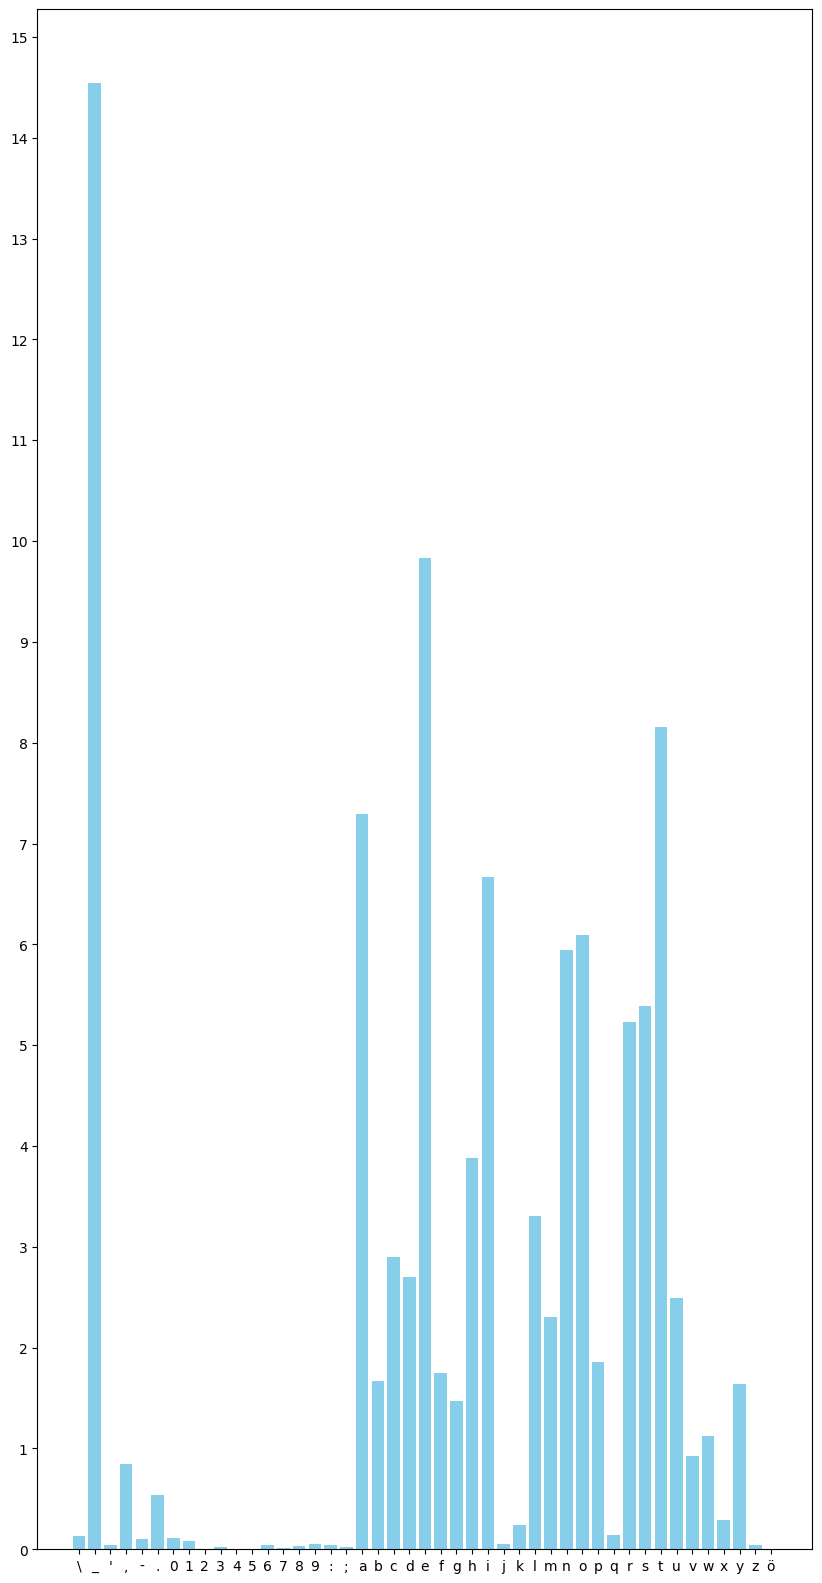

In [7]:
frecuency_chars,index_char=sample_from_character_distribution(characters_list,char_count)
plt.figure(figsize=(10, 20))
plt.bar(unique_chars_bar, frecuency_chars, color='skyblue')
plt.yticks(range(0, 16,1))

**GENERATE RANDOM TEXT**

In [8]:
frecuency_chars,index_char=sample_from_character_distribution(characters_list,char_count)
#Join all the random characters selected by a random index in the list with each individual char of the initial text
random_text="".join(unique_chars[index_char])
print(random_text)

od roosssm     ltesnutao   eh a taolrwsitrpaonhret tu.o itnsnrh hnd e o ioiacawg wsneymdoiia  aserannehycaio p yv raeatateeitab fw rftsgdeforcwnnwaeo ennr tost afnttalyenteosseteyrtbobpur tmiaanmatur e bdoed tum iya  tpehysyef,eessarnoeor  hs ns b-i  d mm  i  nth,enoeggv oi mdsueneraeoilnetrato nlgo  afnitim  o dse-fsiitfyiip itoti rte ipaog tmrenas eylfnh fo ses rgn, t1slo htmscmg fa hit  i hd lear o ciwhfrhaupe otiu,tartnwpia9unab iaeah n etnntecmnn ifnng soeleossdn  ehatf tteud mweonssmni n  e ntcv cahst amdftbgtaiercu er rt fo ysnea xlbrmnteuoy iyrrzaefm au bfnu vil eui hlcaueegsvtfstes ys grlalshi egmesumcanlwttetodfgrtirtc eiryo amgbnaeererb g lacraooyacehorenrasn me0h ,ttnsua ksaimrr otsa tigevndifdgnerassk eysic,oneuicfyetmsay oslefleeqgke rttah tnt ret,mo oitt.lh csrfnns sps vunaesdnsvgxnr grp sr htfjheecn..sftonelmi s mihlla yhtsi ei  m to oeergmi ;narawsntin tlig it efayshseneieeialwieeateatedeoy tseglo olhantipuu hscvr pyehswinmnntiaou avuw
1 t lonttqin  pcvelc eota,a  i oc